In [1]:
print("NFHS ready!")

NFHS ready!


In [2]:
import pandas as pd

file_path = r"C:\Users\91981\Downloads\IAKR7EDT\IAKR7EFL.DTA"

df = pd.read_stata(
    file_path,
    convert_categoricals=False
)

print(df.shape)

(232920, 1644)


In [3]:
df.columns.tolist()[:50]

['caseid',
 'midx',
 'v000',
 'v001',
 'v002',
 'v003',
 'v004',
 'v005',
 'v006',
 'v007',
 'v008',
 'v008a',
 'v009',
 'v010',
 'v011',
 'v012',
 'v013',
 'v014',
 'v015',
 'v016',
 'v017',
 'v018',
 'v019',
 'v019a',
 'v020',
 'v021',
 'v022',
 'v023',
 'v024',
 'v025',
 'v026',
 'v027',
 'v028',
 'v029',
 'v030',
 'v031',
 'v032',
 'v034',
 'v040',
 'v042',
 'v044',
 'v045a',
 'v045b',
 'v045c',
 'v046',
 'v101',
 'v102',
 'v103',
 'v104',
 'v105']

In [4]:
[x for x in df.columns if "70" in x]

['v170',
 'v701',
 'v702',
 'v704',
 'v704a',
 'v705',
 'm70',
 'hw70',
 's370a',
 's370b',
 's370c',
 's370d',
 's370e',
 's370f',
 's370g',
 's370h',
 's370i',
 's370j',
 's370k',
 's370l',
 's370x',
 's704',
 's707',
 's708',
 's709',
 's470']

In [5]:
for col in ["v005","v024","v190","hw70"]:
    print(col, col in df.columns)

v005 True
v024 True
v190 True
hw70 True


In [6]:
df.shape

(232920, 1644)

In [7]:
df["hw70"].describe()

count    211089.000000
mean        111.830337
std        1560.529676
min        -600.000000
25%        -243.000000
50%        -140.000000
75%         -26.000000
max        9998.000000
Name: hw70, dtype: float64

In [8]:
df["hw70"].isna().sum()

np.int64(21831)

In [9]:
df["hw70"].count()

np.int64(211089)

In [10]:
df["hw70"].value_counts().tail(20)

hw70
567.0    8
572.0    8
564.0    8
591.0    8
535.0    7
571.0    7
557.0    7
581.0    7
565.0    7
577.0    7
514.0    7
543.0    6
559.0    6
579.0    6
552.0    5
551.0    5
490.0    5
587.0    5
598.0    4
593.0    3
Name: count, dtype: int64

In [11]:
import numpy as np

df["hw70_clean"] = df["hw70"]
df.loc[df["hw70_clean"] >= 9996, "hw70_clean"] = np.nan

C:\Users\91981\AppData\Local\Temp\ipykernel_51492\794617911.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hw70_clean"] = df["hw70"]


In [12]:
df["hw70_clean"].describe()

count    206025.000000
mean       -131.167087
std         183.679119
min        -600.000000
25%        -245.000000
50%        -145.000000
75%         -36.000000
max         600.000000
Name: hw70_clean, dtype: float64

In [13]:
df["stunted"] = (df["hw70_clean"] < -200).astype(int)

C:\Users\91981\AppData\Local\Temp\ipykernel_51492\3940554414.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["stunted"] = (df["hw70_clean"] < -200).astype(int)


In [14]:
df["stunted"].value_counts(dropna=False)

stunted
0    159848
1     73072
Name: count, dtype: int64

In [15]:
df["stunted"].mean()

np.float64(0.31372144942469515)

In [16]:
import numpy as np

df["weight"] = df["v005"] / 1000000

valid = df[df["hw70_clean"].notna()]

np.average(
    valid["stunted"],
    weights=valid["weight"]
)

C:\Users\91981\AppData\Local\Temp\ipykernel_51492\3995798654.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["weight"] = df["v005"] / 1000000


np.float64(0.35472403072370645)

In [17]:
df["v190"].value_counts()

v190
1    63406
2    54463
3    45083
4    39094
5    30874
Name: count, dtype: int64

In [18]:
df["v190"].value_counts(normalize=True)

v190
1    0.272222
2    0.233827
3    0.193556
4    0.167843
5    0.132552
Name: proportion, dtype: float64

In [19]:
df["v024"].nunique()

36

In [20]:
df["v024"].head()

0    1
1    1
2    1
3    1
4    1
Name: v024, dtype: int8

In [21]:
df["v024"].value_counts().head(10)

v024
9     35766
10    21040
23    16280
8     14643
18    10645
20    10047
24     9868
27     9520
21     8522
22     8514
Name: count, dtype: int64

In [22]:
df["v024"].unique()[:10]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int8)

In [23]:
df["v024"].value_counts().sort_index()

v024
1      5857
2      2635
3      5616
4       174
5      3784
6      6915
7      2937
8     14643
9     35766
10    21040
11      620
12     5524
13     3052
14     3225
15     2454
16     2074
17     6628
18    10645
19     5618
20    10047
21     8522
22     8514
23    16280
24     9868
25      795
27     9520
28     2833
29     8383
30      369
31      276
32     2734
33     6498
34      766
35      461
36     7318
37      529
Name: count, dtype: int64

In [24]:
df["v190"].value_counts().sort_index()

v190
1    63406
2    54463
3    45083
4    39094
5    30874
Name: count, dtype: int64

In [25]:
poor = valid[valid["v190"] == 1]
rich = valid[valid["v190"] == 5]

poor_rate = np.average(
    poor["stunted"],
    weights=poor["weight"]
)

rich_rate = np.average(
    rich["stunted"],
    weights=rich["weight"]
)

print("Poor:", round(100 * poor_rate, 1), "%")
print("Rich:", round(100 * rich_rate, 1), "%")
print("Gap:", round(100 * (poor_rate - rich_rate), 1), "pp")

Poor: 46.1 %
Rich: 22.9 %
Gap: 23.2 pp


In [26]:
df[["v024"]].drop_duplicates().sort_values("v024")

,v024
0,1
5857,2
8492,3
14108,4
14282,5
18066,6
24981,7
27918,8
42561,9
78327,10


In [27]:
df["v024"].describe()

count    232920.000000
mean         16.411686
std           9.099935
min           1.000000
25%           9.000000
50%          17.000000
75%          23.000000
max          37.000000
Name: v024, dtype: float64

In [28]:
state_results = []

for state in sorted(valid["v024"].unique()):

    state_df = valid[valid["v024"] == state]

    poor = state_df[state_df["v190"] == 1]
    rich = state_df[state_df["v190"] == 5]

    if len(poor) == 0 or len(rich) == 0:
        continue

    poor_rate = np.average(
        poor["stunted"],
        weights=poor["weight"]
    )

    rich_rate = np.average(
        rich["stunted"],
        weights=rich["weight"]
    )

    state_results.append({
        "state_code": state,
        "poor_rate": poor_rate,
        "rich_rate": rich_rate,
        "gap": poor_rate - rich_rate
    })

state_gap = pd.DataFrame(state_results)

state_gap.sort_values(
    "gap",
    ascending=False
).head(10)

,state_code,poor_rate,rich_rate,gap
6,7,0.733802,0.251201,0.482601
16,17,0.514654,0.073898,0.440756
5,6,0.560923,0.196114,0.364809
28,30,0.552777,0.227390,0.325386
20,21,0.432007,0.111035,0.320972
19,20,0.465598,0.173791,0.291806
9,10,0.493919,0.202447,0.291472
2,3,0.478002,0.196496,0.281505
26,28,0.481482,0.205115,0.276367
30,33,0.450602,0.178783,0.271820


In [29]:
state_gap["gap_pp"] = 100 * state_gap["gap"]

state_gap[["state_code", "gap_pp"]]\
    .sort_values("gap_pp", ascending=False)\
    .head(10)

,state_code,gap_pp
6,7,48.260059
16,17,44.075644
5,6,36.480894
28,30,32.538608
20,21,32.097213
19,20,29.180637
9,10,29.147207
2,3,28.150532
26,28,27.636683
30,33,27.181953


In [30]:
!pip install pyreadstat
import pyreadstat
_, meta = pyreadstat.read_dta(
    r"C:\Users\91981\Downloads\IAKR7EDT\IAKR7EFL.DTA",
    metadataonly=True
)

print(meta.variable_to_label.get("v024"))
label_name = meta.variable_to_label["v024"]

meta.value_labels[label_name]



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\91981\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


V024


{1: 'jammu & kashmir',
 2: 'himachal pradesh',
 3: 'punjab',
 4: 'chandigarh',
 5: 'uttarakhand',
 6: 'haryana',
 7: 'nct of delhi',
 8: 'rajasthan',
 9: 'uttar pradesh',
 10: 'bihar',
 11: 'sikkim',
 12: 'arunachal pradesh',
 13: 'nagaland',
 14: 'manipur',
 15: 'mizoram',
 16: 'tripura',
 17: 'meghalaya',
 18: 'assam',
 19: 'west bengal',
 20: 'jharkhand',
 21: 'odisha',
 22: 'chhattisgarh',
 23: 'madhya pradesh',
 24: 'gujarat',
 25: 'dadra & nagar haveli and daman & diu',
 27: 'maharashtra',
 28: 'andhra pradesh',
 29: 'karnataka',
 30: 'goa',
 31: 'lakshadweep',
 32: 'kerala',
 33: 'tamil nadu',
 34: 'puducherry',
 35: 'andaman & nicobar islands',
 36: 'telangana',
 37: 'ladakh'}

In [31]:
state_gap.sort_values("gap_pp", ascending=False)

,state_code,poor_rate,rich_rate,gap,gap_pp
6,7,0.733802,0.251201,0.482601,48.260059
16,17,0.514654,0.073898,0.440756,44.075644
5,6,0.560923,0.196114,0.364809,36.480894
28,30,0.552777,0.227390,0.325386,32.538608
20,21,0.432007,0.111035,0.320972,32.097213
19,20,0.465598,0.173791,0.291806,29.180637
9,10,0.493919,0.202447,0.291472,29.147207
2,3,0.478002,0.196496,0.281505,28.150532
26,28,0.481482,0.205115,0.276367,27.636683
30,33,0.450602,0.178783,0.271820,27.181953


In [32]:
state_sizes = (
    valid.groupby("v024")
    .size()
    .reset_index(name="n")
)

state_sizes.sort_values("n")

,v024,n
3,4,156
29,31,251
28,30,340
33,35,413
35,37,482
10,11,530
24,25,710
32,34,712
15,16,1906
14,15,2259


In [33]:
state_map = {
 1: 'jammu & kashmir',
 2: 'himachal pradesh',
 3: 'punjab',
 4: 'chandigarh',
 5: 'uttarakhand',
 6: 'haryana',
 7: 'nct of delhi',
 8: 'rajasthan',
 9: 'uttar pradesh',
 10: 'bihar',
 11: 'sikkim',
 12: 'arunachal pradesh',
 13: 'nagaland',
 14: 'manipur',
 15: 'mizoram',
 16: 'tripura',
 17: 'meghalaya',
 18: 'assam',
 19: 'west bengal',
 20: 'jharkhand',
 21: 'odisha',
 22: 'chhattisgarh',
 23: 'madhya pradesh',
 24: 'gujarat',
 25: 'dadra & nagar haveli and daman & diu',
 27: 'maharashtra',
 28: 'andhra pradesh',
 29: 'karnataka',
 30: 'goa',
 31: 'lakshadweep',
 32: 'kerala',
 33: 'tamil nadu',
 34: 'puducherry',
 35: 'andaman & nicobar islands',
 36: 'telangana',
 37: 'ladakh'
}
state_gap["state"] = state_gap["state_code"].map(state_map)

final_table = state_gap[
    ["state", "poor_rate", "rich_rate", "gap_pp"]
].copy()

final_table = final_table.sort_values(
    "gap_pp",
    ascending=False
)

final_table.head(15)

,state,poor_rate,rich_rate,gap_pp
6,nct of delhi,0.733802,0.251201,48.260059
16,meghalaya,0.514654,0.073898,44.075644
5,haryana,0.560923,0.196114,36.480894
28,goa,0.552777,0.227390,32.538608
20,odisha,0.432007,0.111035,32.097213
19,jharkhand,0.465598,0.173791,29.180637
9,bihar,0.493919,0.202447,29.147207
2,punjab,0.478002,0.196496,28.150532
26,andhra pradesh,0.481482,0.205115,27.636683
30,tamil nadu,0.450602,0.178783,27.181953


In [34]:
state_gap["state"] = state_gap["state_code"].map(state_map)

state_gap["gap_pp"] = state_gap["gap"] * 100

final_table = state_gap[
    ["state", "poor_rate", "rich_rate", "gap_pp"]
].sort_values(
    "gap_pp",
    ascending=False
)

final_table.head(10)

,state,poor_rate,rich_rate,gap_pp
6,nct of delhi,0.733802,0.251201,48.260059
16,meghalaya,0.514654,0.073898,44.075644
5,haryana,0.560923,0.196114,36.480894
28,goa,0.552777,0.227390,32.538608
20,odisha,0.432007,0.111035,32.097213
19,jharkhand,0.465598,0.173791,29.180637
9,bihar,0.493919,0.202447,29.147207
2,punjab,0.478002,0.196496,28.150532
26,andhra pradesh,0.481482,0.205115,27.636683
30,tamil nadu,0.450602,0.178783,27.181953


In [35]:
final_table = final_table.copy()

final_table["poor_pct"] = (
    final_table["poor_rate"] * 100
).round(1)

final_table["rich_pct"] = (
    final_table["rich_rate"] * 100
).round(1)

final_table["gap_pp"] = (
    final_table["gap_pp"]
).round(1)

final_table.head()

,state,poor_rate,rich_rate,gap_pp,poor_pct,rich_pct
6,nct of delhi,0.733802,0.251201,48.3,73.4,25.1
16,meghalaya,0.514654,0.073898,44.1,51.5,7.4
5,haryana,0.560923,0.196114,36.5,56.1,19.6
28,goa,0.552777,0.227390,32.5,55.3,22.7
20,odisha,0.432007,0.111035,32.1,43.2,11.1


In [36]:
final_table.to_csv(
    "state_stunting_gap.csv",
    index=False
)

print("saved")

saved


In [37]:
final_table.nlargest(15, "gap_pp")

,state,poor_rate,rich_rate,gap_pp,poor_pct,rich_pct
6,nct of delhi,0.733802,0.251201,48.3,73.4,25.1
16,meghalaya,0.514654,0.073898,44.1,51.5,7.4
5,haryana,0.560923,0.196114,36.5,56.1,19.6
28,goa,0.552777,0.227390,32.5,55.3,22.7
20,odisha,0.432007,0.111035,32.1,43.2,11.1
19,jharkhand,0.465598,0.173791,29.2,46.6,17.4
9,bihar,0.493919,0.202447,29.1,49.4,20.2
2,punjab,0.478002,0.196496,28.2,47.8,19.6
26,andhra pradesh,0.481482,0.205115,27.6,48.1,20.5
30,tamil nadu,0.450602,0.178783,27.2,45.1,17.9


In [38]:
import matplotlib.pyplot as plt
paper = "#f2ede1"
oxblood = "#8c2f24"
navy = "#2d4a63"
ink = "#1b2a3a"
plt.rcParams["figure.facecolor"] = paper
plt.rcParams["axes.facecolor"] = paper

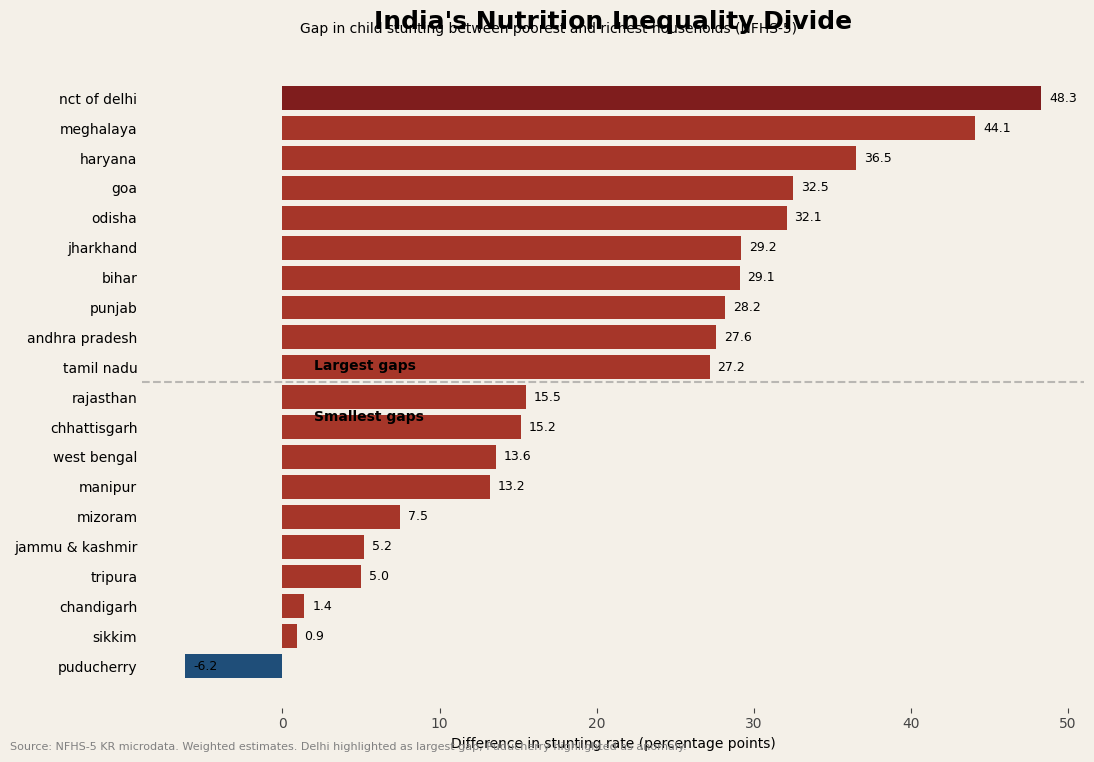

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

paper = "#f4f0e8"
main_red = "#a63629"
highlight_red = "#7f1d1d"
highlight_blue = "#1f4e79"

top10 = final_table.head(10)
bottom10 = final_table.tail(10)

plot_df = pd.concat([top10, bottom10])

colors = []

for state in plot_df["state"]:
    if state == "nct of delhi":
        colors.append(highlight_red)
    elif state == "puducherry":
        colors.append(highlight_blue)
    else:
        colors.append(main_red)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    plot_df["state"],
    plot_df["gap_pp"],
    color=colors
)

ax.invert_yaxis()

for i, value in enumerate(plot_df["gap_pp"]):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}",
        va="center",
        fontsize=9
    )

# divider between top and bottom groups
ax.axhline(
    y=9.5,
    color="gray",
    linestyle="--",
    alpha=0.5
)

ax.text(
    2,
    9.1,
    "Largest gaps",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    2,
    10.8,
    "Smallest gaps",
    fontsize=10,
    fontweight="bold"
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors="#444444")

ax.set_xlabel(
    "Difference in stunting rate (percentage points)",
    fontsize=10
)

ax.set_ylabel("")

plt.title(
    "India's Nutrition Inequality Divide",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.suptitle(
    "Gap in child stunting between poorest and richest households (NFHS-5)",
    fontsize=10,
    y=0.93
)

plt.figtext(
    0.01,
    0.02,
    "Source: NFHS-5 KR microdata. Weighted estimates. Delhi highlighted as largest gap; Puducherry highlighted as anomaly.",
    fontsize=8,
    color="gray"
)

fig.patch.set_facecolor(paper)
ax.set_facecolor(paper)

plt.tight_layout()

plt.savefig(
    "nutrition_gap_ranking.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=paper
)

plt.show()

In [40]:
import os

for f in os.listdir():
    print(f)

pip install geopandas

SyntaxError: invalid syntax (2462771195.py, line 6)

In [41]:
import geopandas as gpd

india = gpd.read_file("india.json")

india.head()

DataSourceError: india.json: No such file or directory

In [42]:
import os

for f in os.listdir():
    print(f)

6928394f91
bin
Code.exe
Code.VisualElementsManifest.xml
nutrition_gap_ranking.png
state_stunting_gap.csv
unins000.dat
unins000.exe
unins000.msg


In [43]:
import json

with open(r"C:\Users\91981\Desktop\Stunting folder\india.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))

if isinstance(data, dict):
    print(data.keys())

<class 'dict'>
dict_keys(['type', 'features'])


In [44]:
import geopandas as gpd

india = gpd.read_file(
    r"C:\Users\91981\Desktop\Stunting folder\india.json"
)

india.head()

,source,id,name,geometry
0,https://simplemaps.com,INAN,Andaman and Nicobar,"MULTIPOLYGON (((93.84805 7.24028, 93.8425 7.22..."
1,https://simplemaps.com,INTG,Telangana,"POLYGON ((77.50945 15.92086, 77.51488 15.96315..."
2,https://simplemaps.com,INAP,Andhra Pradesh,"MULTIPOLYGON (((77.50945 15.92086, 77.58842 15..."
3,https://simplemaps.com,INAR,Arunachal Pradesh,"POLYGON ((95.23763 26.68629, 95.23611 26.71221..."
4,https://simplemaps.com,INAS,Assam,"MULTIPOLYGON (((92.10789 26.89382, 92.12037 26..."


In [45]:
india.columns

Index(['source', 'id', 'name', 'geometry'], dtype='object')

In [46]:
sorted(final_table["state"].unique())

['andaman & nicobar islands',
 'andhra pradesh',
 'arunachal pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra & nagar haveli and daman & diu',
 'goa',
 'gujarat',
 'haryana',
 'himachal pradesh',
 'jammu & kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'madhya pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'nct of delhi',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil nadu',
 'telangana',
 'tripura',
 'uttar pradesh',
 'uttarakhand',
 'west bengal']

In [47]:
import geopandas as gpd

states = gpd.read_file(
    r"C:\Users\91981\Desktop\Stunting folder\india.json"
)

print(len(states))
print(states.columns)
states.head()

36
Index(['source', 'id', 'name', 'geometry'], dtype='object')


,source,id,name,geometry
0,https://simplemaps.com,INAN,Andaman and Nicobar,"MULTIPOLYGON (((93.84805 7.24028, 93.8425 7.22..."
1,https://simplemaps.com,INTG,Telangana,"POLYGON ((77.50945 15.92086, 77.51488 15.96315..."
2,https://simplemaps.com,INAP,Andhra Pradesh,"MULTIPOLYGON (((77.50945 15.92086, 77.58842 15..."
3,https://simplemaps.com,INAR,Arunachal Pradesh,"POLYGON ((95.23763 26.68629, 95.23611 26.71221..."
4,https://simplemaps.com,INAS,Assam,"MULTIPOLYGON (((92.10789 26.89382, 92.12037 26..."


In [48]:
sorted(states["name"].str.lower().unique())

['andaman and nicobar',
 'andhra pradesh',
 'arunachal pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'delhi',
 'dādra and nagar haveli and damān and diu',
 'goa',
 'gujarat',
 'haryana',
 'himachal pradesh',
 'jammu and kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'lakshadweep',
 'madhya pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'orissa',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil nadu',
 'telangana',
 'tripura',
 'uttar pradesh',
 'uttaranchal',
 'west bengal']

In [49]:
sorted(final_table["state"].str.lower().unique())

['andaman & nicobar islands',
 'andhra pradesh',
 'arunachal pradesh',
 'assam',
 'bihar',
 'chandigarh',
 'chhattisgarh',
 'dadra & nagar haveli and daman & diu',
 'goa',
 'gujarat',
 'haryana',
 'himachal pradesh',
 'jammu & kashmir',
 'jharkhand',
 'karnataka',
 'kerala',
 'ladakh',
 'madhya pradesh',
 'maharashtra',
 'manipur',
 'meghalaya',
 'mizoram',
 'nagaland',
 'nct of delhi',
 'odisha',
 'puducherry',
 'punjab',
 'rajasthan',
 'sikkim',
 'tamil nadu',
 'telangana',
 'tripura',
 'uttar pradesh',
 'uttarakhand',
 'west bengal']

In [50]:
states["name_clean"] = (
    states["name"]
    .str.lower()
    .str.strip()
)

final_table["state_clean"] = (
    final_table["state"]
    .str.lower()
    .str.strip()
)





map_data = states.merge(
    final_table,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)

In [51]:
set(final_table["state_clean"]) - set(states["name_clean"])

{'andaman & nicobar islands',
 'dadra & nagar haveli and daman & diu',
 'jammu & kashmir',
 'nct of delhi',
 'odisha',
 'uttarakhand'}

In [52]:
set(states["name_clean"]) - set(final_table["state_clean"])

{'andaman and nicobar',
 'delhi',
 'dādra and nagar haveli and damān and diu',
 'jammu and kashmir',
 'lakshadweep',
 'orissa',
 'uttaranchal'}

In [53]:
final_table["state_clean"] = final_table["state_clean"].replace({
    "andaman & nicobar islands": "andaman and nicobar",
    "dadra & nagar haveli and daman & diu": "dadra and nagar haveli and daman and diu",
    "jammu & kashmir": "jammu and kashmir",
    "nct of delhi": "delhi",
    "odisha": "orissa",
    "uttarakhand": "uttaranchal"
})
map_data = states.merge(
    final_table,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)

In [54]:
map_data.loc[
    map_data["gap_pp"].isna(),
    ["name"]
]

,name
8,Dādra and Nagar Haveli and Damān and Diu
33,Lakshadweep


In [55]:
map_data.loc[
    map_data["gap_pp"].isna(),
    ["name", "name_clean"]
]

,name,name_clean
8,Dādra and Nagar Haveli and Damān and Diu,dādra and nagar haveli and damān and diu
33,Lakshadweep,lakshadweep


In [56]:
states["name_clean"] = states["name_clean"].replace({
    "dādra and nagar haveli and damān and diu":
    "dadra & nagar haveli and daman & diu"
})

In [57]:
map_data = states.merge(
    final_table,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)

In [58]:
map_data.loc[
    map_data["gap_pp"].isna(),
    ["name"]
]

,name
8,Dādra and Nagar Haveli and Damān and Diu
33,Lakshadweep


In [59]:
states.loc[
    states["name_clean"].str.contains("haveli", case=False, na=False),
    ["name", "name_clean"]
]

,name,name_clean
8,Dādra and Nagar Haveli and Damān and Diu,dadra & nagar haveli and daman & diu


In [60]:
final_table.loc[
    final_table["state_clean"].str.contains("haveli", case=False, na=False),
    ["state", "state_clean"]
]

,state,state_clean
24,dadra & nagar haveli and daman & diu,dadra and nagar haveli and daman and diu


In [61]:
final_table["state_clean"] = final_table["state_clean"].replace({
    "dadra & nagar haveli and daman & diu":
    "dadra & nagar haveli and daman & diu"
})

In [62]:
map_data = states.merge(
    final_table,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)

In [63]:
map_data.loc[
    map_data["gap_pp"].isna(),
    ["name"]
]

,name
8,Dādra and Nagar Haveli and Damān and Diu
33,Lakshadweep


In [64]:
print(
    states.loc[
        states["name_clean"].str.contains("haveli", na=False),
        "name_clean"
    ].iloc[0]
)

print(
    final_table.loc[
        final_table["state_clean"].str.contains("haveli", na=False),
        "state_clean"
    ].iloc[0]
)

dadra & nagar haveli and daman & diu
dadra and nagar haveli and daman and diu


In [65]:
final_table["state_clean"] = final_table["state_clean"].replace({
    "dadra and nagar haveli and daman and diu":
    "dadra & nagar haveli and daman & diu"
})

In [66]:
map_data = states.merge(
    final_table,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)

In [67]:
map_data.loc[
    map_data["gap_pp"].isna(),
    ["name"]
]

,name
33,Lakshadweep


In [68]:
map_data.loc[
    map_data["name"] == "Lakshadweep",
    ["name", "gap_pp"]
]

,name,gap_pp
33,Lakshadweep,NaN


In [69]:
missing_kwds={
    "color": "#d9d9d9",
    "label": "No data"
}

In [70]:
map_data["gap_pp"].describe()

count    35.000000
mean     21.328571
std      11.617066
min      -6.200000
25%      15.350000
50%      23.100000
75%      27.400000
max      48.300000
Name: gap_pp, dtype: float64

In [71]:
map_data[["name", "gap_pp"]].head()

,name,gap_pp
0,Andaman and Nicobar,22.6
1,Telangana,23.1
2,Andhra Pradesh,27.6
3,Arunachal Pradesh,17.0
4,Assam,19.7


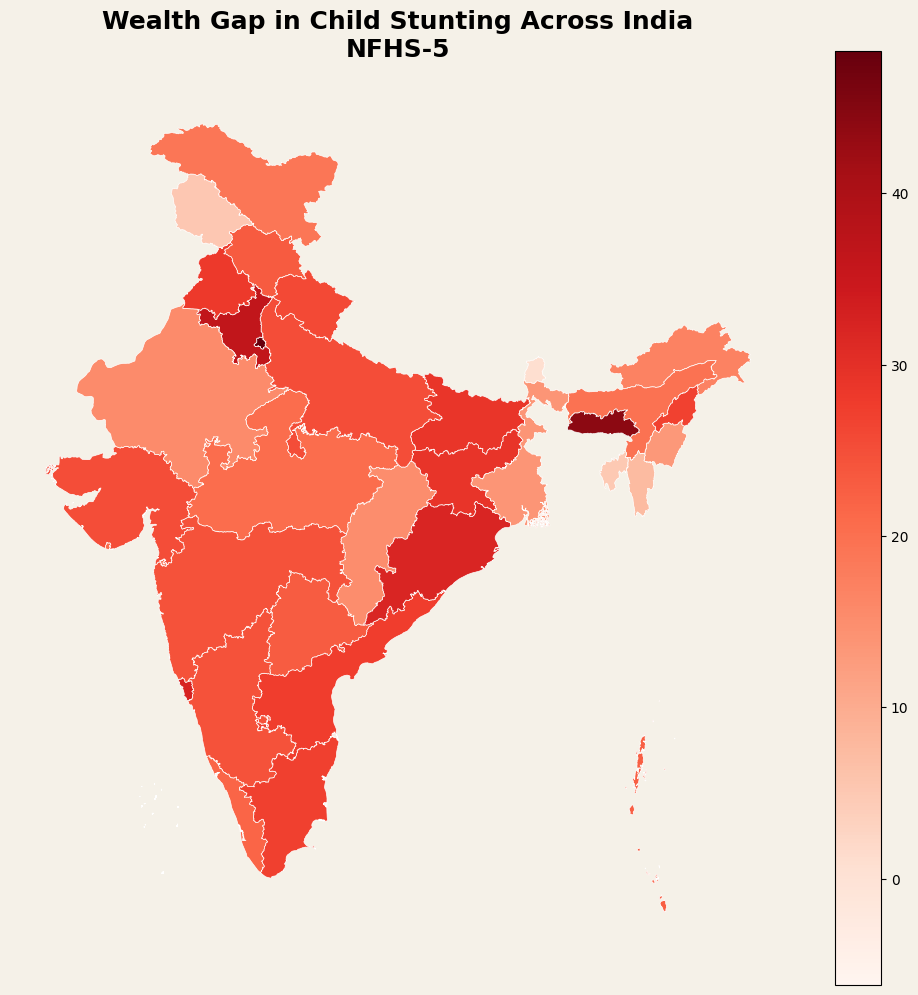

In [74]:
import matplotlib.pyplot as plt

paper = "#f5f1e8"

fig, ax = plt.subplots(figsize=(10, 10))

map_data.plot(
    column="gap_pp",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "#d9d9d9",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "Wealth Gap in Child Stunting Across India\nNFHS-5",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.axis("off")

fig.patch.set_facecolor(paper)
ax.set_facecolor(paper)

plt.tight_layout()
plt.show()

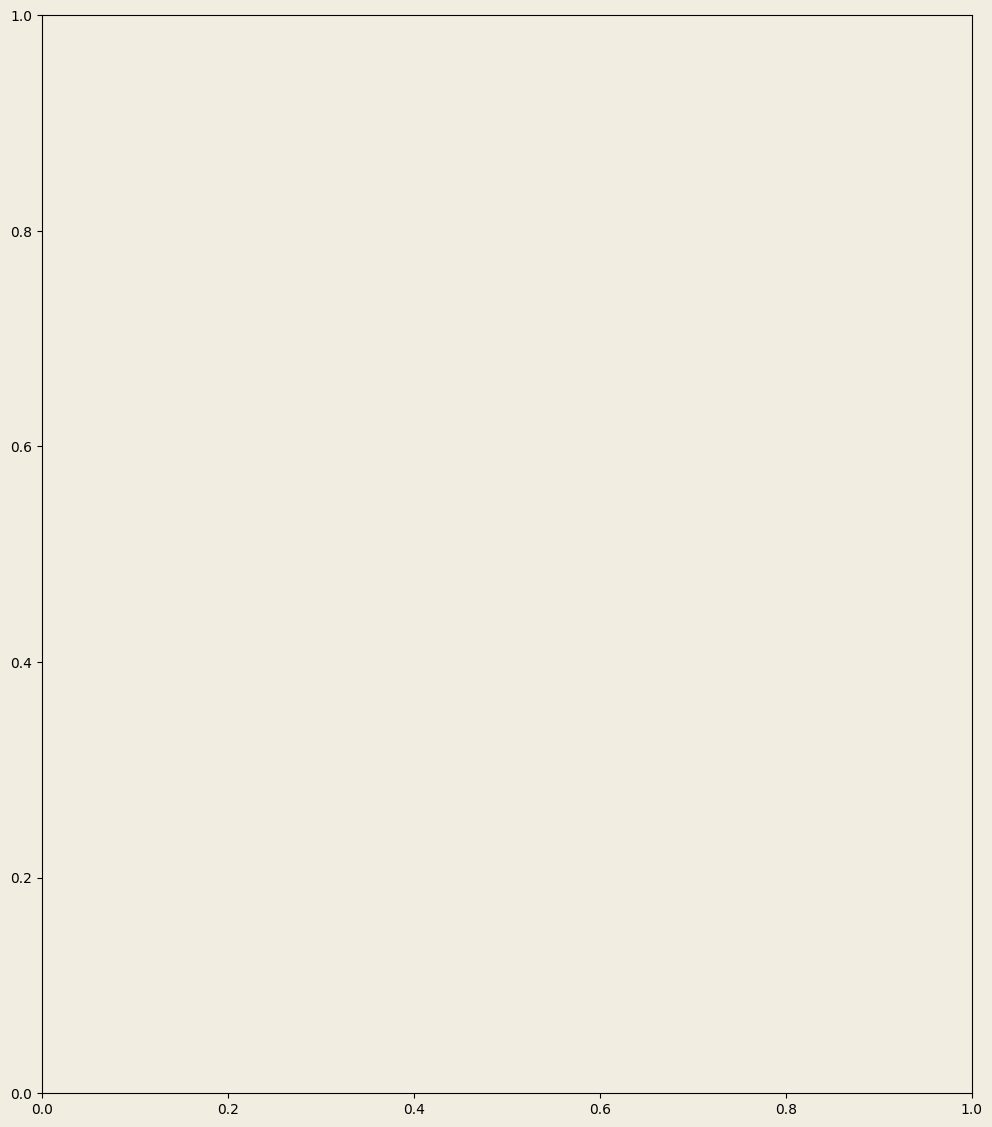

In [76]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "wealth_gap",
    [
        "#f7efe3",
        "#f2c9a5",
        "#e88d67",
        "#d85a42",
        "#a82e25"
    ]
)

legend=False

fig, ax = plt.subplots(
    figsize=(12, 14)
)

fontsize=22

In [77]:
map_data.nlargest(
    10,
    "gap_pp"
)[["name","gap_pp"]]

,name,gap_pp
9,Delhi,48.3
20,Meghalaya,44.1
12,Haryana,36.5
10,Goa,32.5
23,Orissa,32.1
14,Jharkhand,29.2
5,Bihar,29.1
25,Punjab,28.2
2,Andhra Pradesh,27.6
28,Tamil Nadu,27.2


In [78]:
map_data.nsmallest(
    10,
    "gap_pp"
)[["name","gap_pp"]]

,name,gap_pp
24,Puducherry,-6.2
27,Sikkim,0.9
6,Chandigarh,1.4
29,Tripura,5.0
34,Jammu and Kashmir,5.2
21,Mizoram,7.5
19,Manipur,13.2
32,West Bengal,13.6
7,Chhattisgarh,15.2
26,Rajasthan,15.5


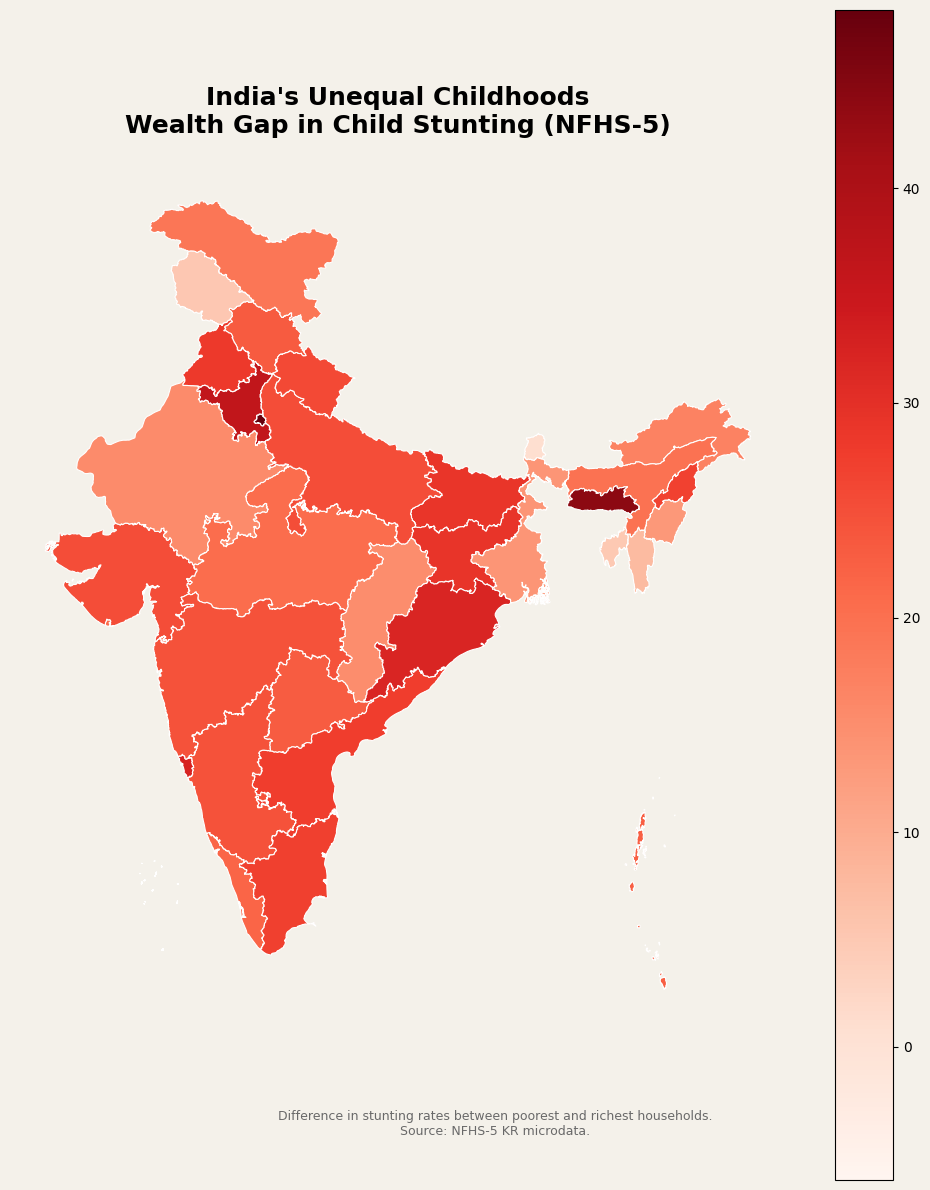

In [79]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,12))

paper = "#f4f1ea"

fig.patch.set_facecolor(paper)
ax.set_facecolor(paper)

map_data.plot(
    column="gap_pp",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="white",
    missing_kwds={
        "color":"lightgrey",
        "label":"No data"
    },
    legend=True,
    ax=ax
)

ax.set_title(
    "India's Unequal Childhoods\n"
    "Wealth Gap in Child Stunting (NFHS-5)",
    fontsize=18,
    weight="bold",
    pad=20
)

ax.axis("off")

plt.figtext(
    0.5,
    0.05,
    "Difference in stunting rates between poorest and richest households.\nSource: NFHS-5 KR microdata.",
    ha="center",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()

plt.show()

In [80]:
delhi = map_data[map_data["name"]=="Delhi"]

x = delhi.geometry.centroid.x.iloc[0]
y = delhi.geometry.centroid.y.iloc[0]

ax.annotate(
    "Delhi\n48.3 pp",
    xy=(x,y),
    xytext=(74,32),
    arrowprops=dict(arrowstyle="-"),
    fontsize=10
)

C:\Users\91981\AppData\Local\Temp\ipykernel_51492\275701458.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x = delhi.geometry.centroid.x.iloc[0]
C:\Users\91981\AppData\Local\Temp\ipykernel_51492\275701458.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y = delhi.geometry.centroid.y.iloc[0]


Text(74, 32, 'Delhi\n48.3 pp')

In [81]:
pud = map_data[map_data["name"]=="Puducherry"]

x = pud.geometry.centroid.x.iloc[0]
y = pud.geometry.centroid.y.iloc[0]

ax.annotate(
    "Puducherry\n-6.2 pp",
    xy=(x,y),
    xytext=(84,10),
    arrowprops=dict(arrowstyle="-"),
    fontsize=10
)

C:\Users\91981\AppData\Local\Temp\ipykernel_51492\2123451832.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x = pud.geometry.centroid.x.iloc[0]
C:\Users\91981\AppData\Local\Temp\ipykernel_51492\2123451832.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y = pud.geometry.centroid.y.iloc[0]


Text(84, 10, 'Puducherry\n-6.2 pp')

In [83]:
#figure 0
income_data = {
    "state": [
        "andhra pradesh",
        "assam",
        "bihar",
        "chhattisgarh",
        "goa",
        "gujarat",
        "haryana",
        "himachal pradesh",
        "jharkhand",
        "karnataka",
        "kerala",
        "madhya pradesh",
        "maharashtra",
        "manipur",
        "meghalaya",
        "mizoram",
        "nagaland",
        "odisha",
        "punjab",
        "rajasthan",
        "sikkim",
        "tamil nadu",
        "telangana",
        "tripura",
        "uttar pradesh",
        "uttarakhand",
        "west bengal",
        "andaman & nicobar islands",
        "chandigarh",
        "nct of delhi",
        "jammu & kashmir",
        "puducherry"
    ],

    "income_pc": [
        163746,
        90482,
        43605,
        104788,
        431351,
        212821,
        229065,
        183333,
        71071,
        221310,
        194322,
        103654,
        183704,
        79797,
        84638,
        187838,
        126452,
        102166,
        149193,
        115122,
        412754,
        212174,
        225687,
        119789,
        61374,
        184002,
        106510,
        197275,
        291194,
        331112,
        102803,
        203178
    ]
}

income = pd.DataFrame(income_data)
income["state_clean"] = income["state"]

income["state_clean"] = income["state_clean"].replace({
    "andaman & nicobar islands": "andaman and nicobar",
    "nct of delhi": "delhi",
    "jammu & kashmir": "jammu and kashmir",
    "odisha": "orissa",
    "uttarakhand": "uttaranchal"
})

cartogram_data = states.merge(
    income,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)

cartogram_data[["name", "income_pc"]].head()

,name,income_pc
0,Andaman and Nicobar,197275.0
1,Telangana,225687.0
2,Andhra Pradesh,163746.0
3,Arunachal Pradesh,NaN
4,Assam,90482.0


In [84]:
cartogram_data.loc[
    cartogram_data["income_pc"].isna(),
    ["name"]
]

,name
3,Arunachal Pradesh
8,Dādra and Nagar Haveli and Damān and Diu
33,Lakshadweep
35,Ladakh


In [85]:
from shapely.affinity import scale
import numpy as np

In [86]:
median_income = cartogram_data["income_pc"].median()

cartogram_data["scale_factor"] = (
    cartogram_data["income_pc"] / median_income
) ** 0.5

In [87]:
cartogram_data["cartogram_geometry"] = cartogram_data.apply(
    lambda row: scale(
        row.geometry,
        xfact=row.scale_factor,
        yfact=row.scale_factor,
        origin="centroid"
    )
    if pd.notnull(row.income_pc)
    else row.geometry,
    axis=1
)

In [88]:
import geopandas as gpd

cartogram = gpd.GeoDataFrame(
    cartogram_data.copy(),
    geometry="cartogram_geometry",
    crs=states.crs
)

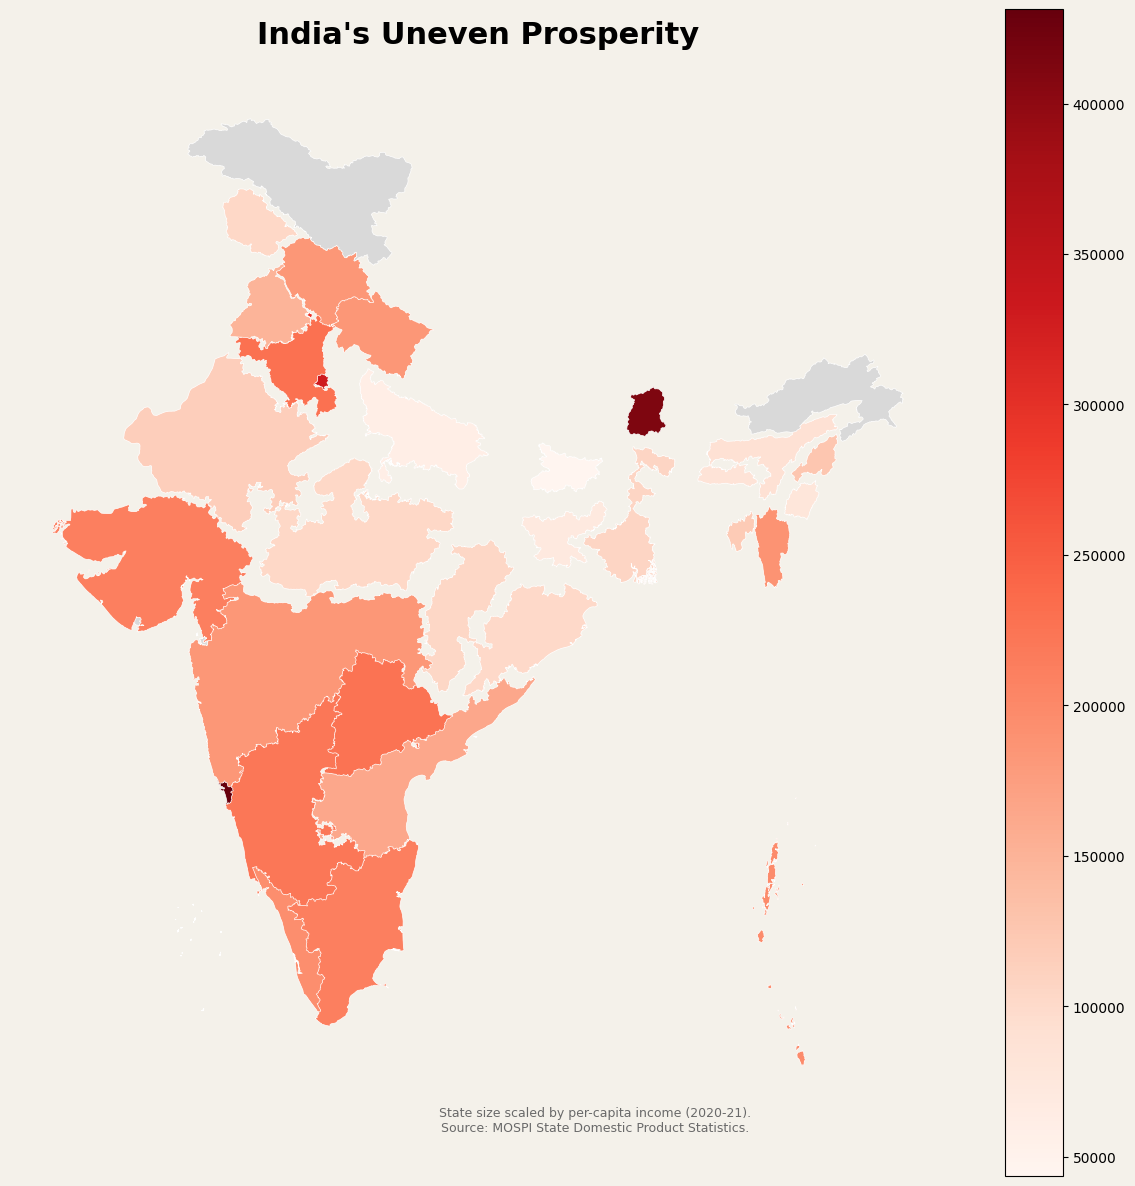

In [89]:
import matplotlib.pyplot as plt

paper = "#f4f1ea"

fig, ax = plt.subplots(figsize=(12,12))

cartogram.plot(
    column="income_pc",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
    legend=True,
    missing_kwds={
        "color": "#d9d9d9",
        "label": "No data"
    }
)

ax.set_title(
    "India's Uneven Prosperity",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.figtext(
    0.5,
    0.05,
    "State size scaled by per-capita income (2020-21).\nSource: MOSPI State Domestic Product Statistics.",
    ha="center",
    fontsize=9,
    color="dimgray"
)

ax.axis("off")

fig.patch.set_facecolor(paper)
ax.set_facecolor(paper)

plt.tight_layout()
plt.show()

In [90]:
cartogram_data[["name","income_pc"]].sort_values(
    "income_pc",
    ascending=False
).head(10)

,name,income_pc
10,Goa,431351.0
27,Sikkim,412754.0
9,Delhi,331112.0
6,Chandigarh,291194.0
12,Haryana,229065.0
1,Telangana,225687.0
15,Karnataka,221310.0
11,Gujarat,212821.0
28,Tamil Nadu,212174.0
24,Puducherry,203178.0


In [91]:
cartogram_data["income_pc"].describe()

count        32.000000
mean     172697.187500
std       93809.864348
min       43605.000000
25%      103441.250000
50%      173539.500000
75%      212335.750000
max      431351.000000
Name: income_pc, dtype: float64

In [109]:
#figure 0
centroids = cartogram_data.copy()

centroids["x"] = centroids.geometry.centroid.x
centroids["y"] = centroids.geometry.centroid.y

centroids[["name", "income_pc"]].head()

C:\Users\91981\AppData\Local\Temp\ipykernel_51492\2840944954.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["x"] = centroids.geometry.centroid.x
C:\Users\91981\AppData\Local\Temp\ipykernel_51492\2840944954.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["y"] = centroids.geometry.centroid.y


,name,income_pc
0,Andaman and Nicobar,197275.0
1,Telangana,225687.0
2,Andhra Pradesh,163746.0
3,Arunachal Pradesh,NaN
4,Assam,90482.0


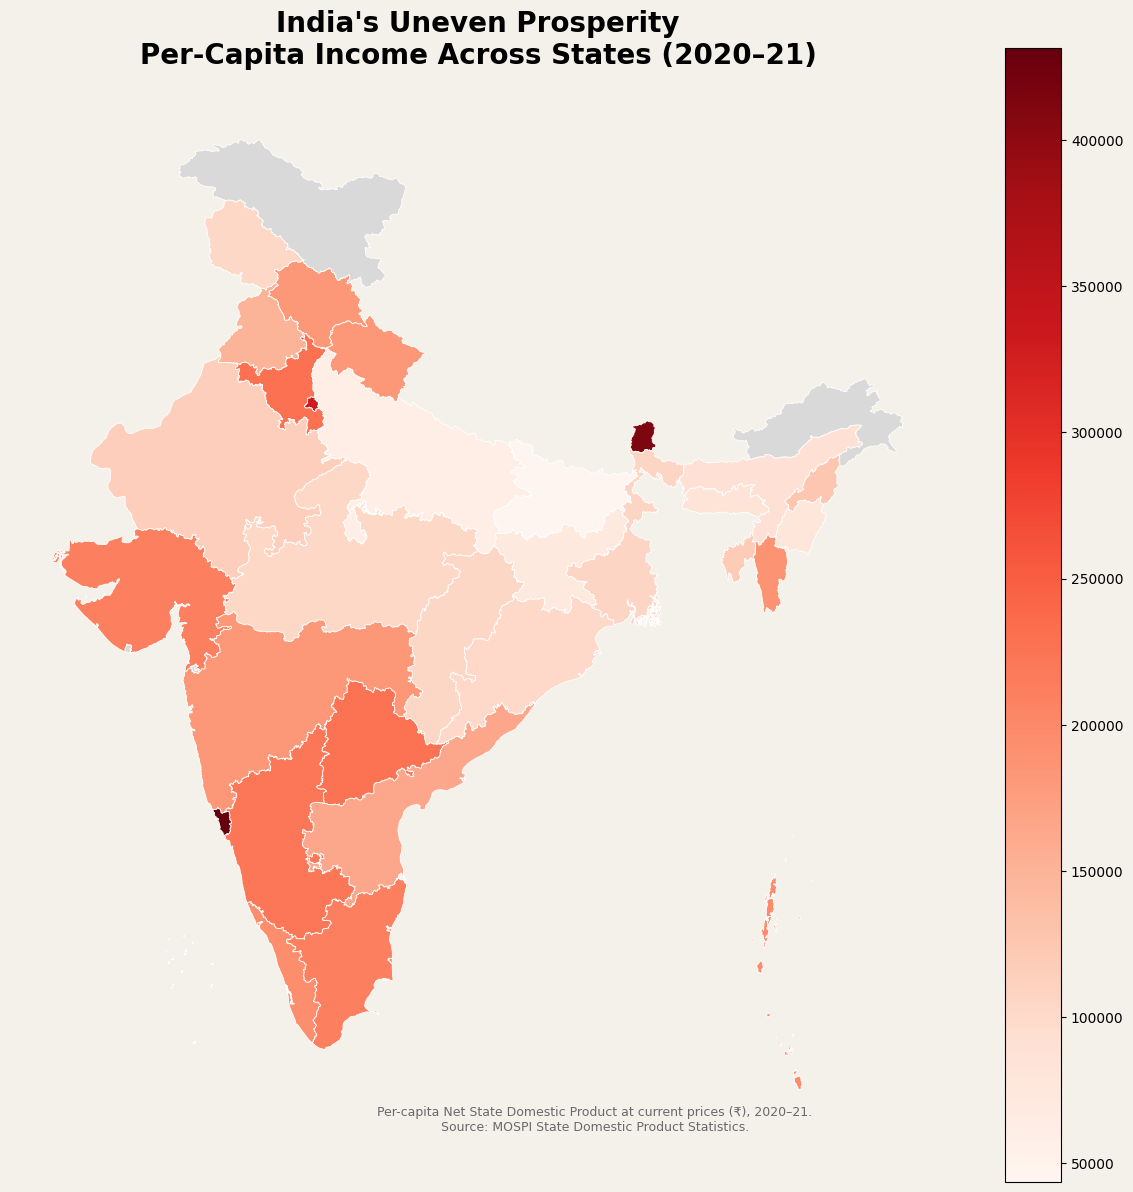

In [117]:
import matplotlib.pyplot as plt

paper = "#f4f1ea"

fig, ax = plt.subplots(figsize=(12, 12))

cartogram_data.plot(
    column="income_pc",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "#d9d9d9",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "India's Uneven Prosperity\nPer-Capita Income Across States (2020–21)",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.figtext(
    0.5,
    0.055,
    "Per-capita Net State Domestic Product at current prices (₹), 2020–21.\nSource: MOSPI State Domestic Product Statistics.",
    ha="center",
    fontsize=9,
    color="dimgray"
)

ax.axis("off")

fig.patch.set_facecolor(paper)
ax.set_facecolor(paper)

plt.tight_layout()

plt.savefig(
    "figure0_prosperity_map.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=paper
)

plt.show()

In [113]:
centroids.nlargest(10, "income_pc")[["name", "income_pc"]]

,name,income_pc
10,Goa,431351.0
27,Sikkim,412754.0
9,Delhi,331112.0
6,Chandigarh,291194.0
12,Haryana,229065.0
1,Telangana,225687.0
15,Karnataka,221310.0
11,Gujarat,212821.0
28,Tamil Nadu,212174.0
24,Puducherry,203178.0


In [ ]:
#figure 1

In [92]:
import numpy as np
import pandas as pd

state_stunting = (
    valid.groupby("v024")
    .apply(
        lambda x: np.average(
            x["stunted"],
            weights=x["weight"]
        )
    )
    .reset_index(name="stunting_rate")
)

C:\Users\91981\AppData\Local\Temp\ipykernel_51492\3811610039.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [93]:
state_stunting["stunting_pct"] = (
    state_stunting["stunting_rate"] * 100
)

In [94]:
state_stunting["state"] = (
    state_stunting["v024"]
    .map(state_map)
)

In [95]:
state_stunting.sort_values(
    "stunting_pct",
    ascending=False
).head(10)

,v024,stunting_rate,stunting_pct,state
16,17,0.465583,46.558283,meghalaya
9,10,0.429464,42.946369,bihar
19,20,0.396375,39.637475,jharkhand
8,9,0.395815,39.581511,uttar pradesh
24,25,0.393662,39.366240,dadra & nagar haveli and daman & diu
23,24,0.390398,39.039771,gujarat
22,23,0.355826,35.582637,madhya pradesh
25,27,0.354367,35.436685,maharashtra
27,29,0.353964,35.396403,karnataka
17,18,0.352995,35.299508,assam


In [96]:
state_stunting.sort_values(
    "stunting_pct"
).head(10)

,v024,stunting_rate,stunting_pct,state
32,34,0.200963,20.096343,puducherry
10,11,0.223309,22.330891,sikkim
33,35,0.225190,22.519004,andaman & nicobar islands
30,32,0.233563,23.356308,kerala
13,14,0.233722,23.372243,manipur
2,3,0.244588,24.458780,punjab
31,33,0.250609,25.060908,tamil nadu
3,4,0.251112,25.111202,chandigarh
28,30,0.257493,25.749283,goa
0,1,0.268913,26.891338,jammu & kashmir


In [97]:
state_stunting["state_clean"] = (
    state_stunting["state"]
)

In [100]:
state_stunting["state_clean"] = (
    state_stunting["state_clean"]
    .replace({
        "andaman & nicobar islands": "andaman and nicobar",
        "nct of delhi": "delhi",
        "jammu & kashmir": "jammu and kashmir",
        "odisha": "orissa",
        "uttarakhand": "uttaranchal"
    })
)
stunting_map = states.merge(
    state_stunting,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)
stunting_map["stunting_pct"].isna().sum()

np.int64(0)

In [101]:
state_stunting["state_clean"] = state_stunting["state"]

state_stunting["state_clean"] = state_stunting["state_clean"].replace({
    "andaman & nicobar islands": "andaman and nicobar",
    "jammu & kashmir": "jammu and kashmir",
    "odisha": "orissa",
    "uttarakhand": "uttaranchal",
    "nct of delhi": "delhi"
})

In [102]:
stunting_map = states.merge(
    state_stunting,
    left_on="name_clean",
    right_on="state_clean",
    how="left"
)

In [103]:
stunting_map.loc[
    stunting_map["stunting_pct"].isna(),
    ["name"]
]

,name


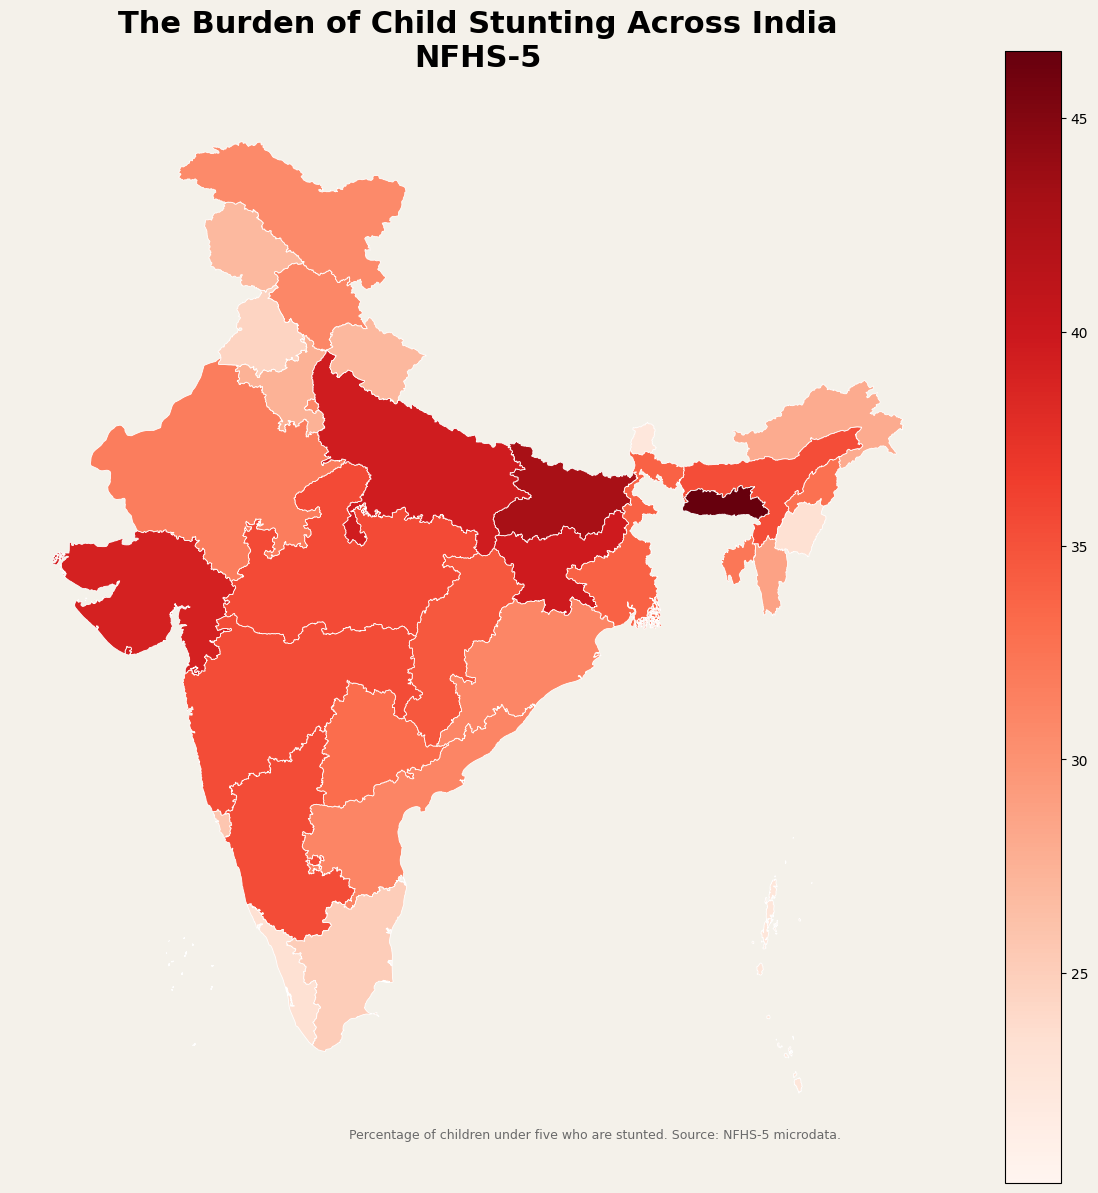

In [104]:
import matplotlib.pyplot as plt

paper = "#f4f1ea"

fig, ax = plt.subplots(figsize=(12,12))

stunting_map.plot(
    column="stunting_pct",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={
        "color":"#d9d9d9",
        "label":"No data"
    }
)

ax.set_title(
    "The Burden of Child Stunting Across India\nNFHS-5",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.figtext(
    0.5,
    0.05,
    "Percentage of children under five who are stunted. Source: NFHS-5 microdata.",
    ha="center",
    fontsize=9,
    color="dimgray"
)

ax.axis("off")

fig.patch.set_facecolor(paper)
ax.set_facecolor(paper)

plt.tight_layout()
plt.show()

In [105]:
states["name"].sort_values().tolist()

['Andaman and Nicobar',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Delhi',
 'Dādra and Nagar Haveli and Damān and Diu',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Orissa',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttaranchal',
 'West Bengal']

In [106]:
states.loc[
    states["name"].str.contains("Lak", case=False, na=False),
    ["name"]
]

,name
33,Lakshadweep
